# Part 1: Road Network (Search Algorithms)

PakTravel is Pakistan's first AI-powered road travel company operating buses across 15 major cities.

Example Scenario: Ali opens the PakTravel app and types: 'I want to go from Karachi to Multan.' The AI must find the best
route. Sometimes there is no direct bus the system must plan a RELAY journey where Ali changes buses
at an intermediate city.

## Task 1: Build the Road Network

In [ ]:
# Part 1 Task 1: Build the Road Network

# 1. Represent the road network as a weighted adjacency dictionary
# We treat the roads as bidirectional to allow travel in both directions.
road_network = {
    'Karachi': {'Hyderabad': 160, 'Quetta': 700},
    'Hyderabad': {'Karachi': 160, 'Sukkur': 380},
    'Sukkur': {'Hyderabad': 380, 'Larkana': 80, 'Multan': 320, 'Bahawalpur': 400},
    'Larkana': {'Sukkur': 80},
    'Bahawalpur': {'Sukkur': 400, 'Multan': 180},
    'Multan': {'Sukkur': 320, 'Bahawalpur': 180, 'Lahore': 340, 'Faisalabad': 270, 'Quetta': 570},
    'Lahore': {'Multan': 340, 'Faisalabad': 130, 'Gujranwala': 80, 'Islamabad': 380},
    'Faisalabad': {'Multan': 270, 'Lahore': 130, 'Gujranwala': 90},
    'Gujranwala': {'Lahore': 80, 'Faisalabad': 90, 'Sialkot': 70},
    'Sialkot': {'Gujranwala': 70},
    'Islamabad': {'Lahore': 380, 'Rawalpindi': 15, 'Peshawar': 170},
    'Rawalpindi': {'Islamabad': 15, 'Peshawar': 155},
    'Peshawar': {'Islamabad': 170, 'Rawalpindi': 155},
    'Quetta': {'Multan': 570, 'Karachi': 700, 'Gwadar': 650},
    'Gwadar': {'Quetta': 650}
}

# 2. Define the exact lists of cities and relay points from the project brief
cities = list(road_network.keys())
relay_points = ['Sukkur', 'Multan', 'Lahore', 'Islamabad', 'Rawalpindi', 'Faisalabad']

# 3. Print all cities, roads, and relay points
print("--- 15 Total Cities ---")
for city in cities:
  print(city, end=", ")
print("\n")

print("--- Road Network (Distances in KM) ---")
# Use a set to track printed pairs so we don't print "A to B" and "B to A" twice
printed_roads = set()
for city, connections in road_network.items():
    for destination, distance in connections.items():
        # Sort the pair alphabetically to create a consistent tracking tuple
        road = tuple(sorted([city, destination]))
        if road not in printed_roads:
            print(f"{city} <-> {destination}: {distance} KM")
            printed_roads.add(road)
print("\n")

print("--- Relay Points (For Changing Buses) ---")
print(", ".join(relay_points))

--- 15 Total Cities ---
Karachi, Hyderabad, Sukkur, Larkana, Bahawalpur, Multan, Lahore, Faisalabad, Gujranwala, Sialkot, Islamabad, Rawalpindi, Peshawar, Quetta, Gwadar, 

--- Road Network (Distances in KM) ---
Karachi <-> Hyderabad: 160 KM
Karachi <-> Quetta: 700 KM
Hyderabad <-> Sukkur: 380 KM
Sukkur <-> Larkana: 80 KM
Sukkur <-> Multan: 320 KM
Sukkur <-> Bahawalpur: 400 KM
Bahawalpur <-> Multan: 180 KM
Multan <-> Lahore: 340 KM
Multan <-> Faisalabad: 270 KM
Multan <-> Quetta: 570 KM
Lahore <-> Faisalabad: 130 KM
Lahore <-> Gujranwala: 80 KM
Lahore <-> Islamabad: 380 KM
Faisalabad <-> Gujranwala: 90 KM
Gujranwala <-> Sialkot: 70 KM
Islamabad <-> Rawalpindi: 15 KM
Islamabad <-> Peshawar: 170 KM
Rawalpindi <-> Peshawar: 155 KM
Quetta <-> Gwadar: 650 KM


--- Relay Points (For Changing Buses) ---
Sukkur, Multan, Lahore, Islamabad, Rawalpindi, Faisalabad


## Task 2: UCS Cheapest Route

In [ ]:
import heapq

def uniform_cost_search(graph, start, goal):
    # Priority queue stores tuples of: (cumulative_distance, current_city, path_taken)
    frontier = [(0, start, [start])]

    # Dictionary to keep track of the minimum cost to reach each explored city
    # This prevents infinite loops and ensures we only process a city again if we find a strictly shorter route
    explored = {start: 0}

    while frontier:
        # Pop the city with the lowest cumulative distance from the priority queue
        current_distance, current_city, path = heapq.heappop(frontier)

        # If we have reached the destination, calculate stops and return
        if current_city == goal:
            # Number of stops is the total cities in the path minus 2 (excluding start and end cities)
            num_stops = max(0, len(path) - 2)
            return path, current_distance, num_stops

        # Explore neighboring cities
        for neighbor, travel_distance in graph.get(current_city, {}).items():
            new_distance = current_distance + travel_distance

            # If the neighbor is unvisited or we found a cheaper path to it
            if neighbor not in explored or new_distance < explored[neighbor]:
                explored[neighbor] = new_distance
                # Push the new path into the priority queue
                heapq.heappush(frontier, (new_distance, neighbor, path + [neighbor]))

    # Return empty values if no path exists
    return None, 0, 0


# Test the 3 required journeys [cite: 77, 78, 79, 80, 81, 82, 83]
journeys = [
    ("Karachi", "Multan"),      # Ali's journey
    ("Karachi", "Peshawar"),
    ("Gwadar", "Islamabad")
]

print("--- UCS Journey Results ---")
for start, dest in journeys:
    path, total_distance, stops = uniform_cost_search(road_network, start, dest)

    # Format and print the required output for each journey [cite: 84]
    print(f"Journey: {start} -> {dest}")
    if path:
        print(f"Path taken: {' -> '.join(path)}")
        print(f"Total distance: {total_distance} KM")
        print(f"Number of stops: {stops}\n")
    else:
        print("Status: No path could be found.\n")

--- UCS Journey Results ---
Journey: Karachi -> Multan
Path taken: Karachi -> Hyderabad -> Sukkur -> Multan
Total distance: 860 KM
Number of stops: 2

Journey: Karachi -> Peshawar
Path taken: Karachi -> Hyderabad -> Sukkur -> Multan -> Lahore -> Islamabad -> Peshawar
Total distance: 1750 KM
Number of stops: 5

Journey: Gwadar -> Islamabad
Path taken: Gwadar -> Quetta -> Multan -> Lahore -> Islamabad
Total distance: 1940 KM
Number of stops: 3



## Task 3: A* Search

In [ ]:
import heapq

# 1. Define the heuristics (straight-line distances to Islamabad)
heuristics_islamabad = {
    'Karachi': 1400, 'Hyderabad': 1250, 'Sukkur': 900, 'Larkana': 920,
    'Bahawalpur': 620, 'Multan': 550, 'Lahore': 380, 'Faisalabad': 300,
    'Gujranwala': 280, 'Sialkot': 300, 'Islamabad': 0, 'Rawalpindi': 15,
    'Peshawar': 170, 'Quetta': 750, 'Gwadar': 1500
}

def a_star_search(graph, start, goal, heuristics):
    # Priority queue stores tuples of: (f_cost, g_cost, current_city, path_taken)
    # f_cost = g_cost (actual distance so far) + h_cost (heuristic distance to goal)
    initial_f = heuristics.get(start, float('inf'))
    frontier = [(initial_f, 0, start, [start])]

    # Dictionary to track the lowest g_cost to reach each city
    explored = {}
    nodes_explored_count = 0

    while frontier:
        f_cost, current_g, current_city, path = heapq.heappop(frontier)
        nodes_explored_count += 1

        # If we reached the goal, return the path details
        if current_city == goal:
            num_stops = max(0, len(path) - 2)
            return path, current_g, num_stops, nodes_explored_count

        # If we've already found a shorter actual path to this city, skip it
        if current_city in explored and explored[current_city] <= current_g:
            continue

        explored[current_city] = current_g

        # Explore neighbors
        for neighbor, travel_distance in graph.get(current_city, {}).items():
            new_g = current_g + travel_distance
            new_f = new_g + heuristics.get(neighbor, float('inf'))

            # Only add to frontier if we found a strictly better g_cost for the neighbor
            if neighbor not in explored or new_g < explored.get(neighbor, float('inf')):
                heapq.heappush(frontier, (new_f, new_g, neighbor, path + [neighbor]))

    return None, 0, 0, nodes_explored_count

def ucs_with_count(graph, start, goal):
    frontier = [(0, start, [start])]
    explored = {}
    nodes_explored_count = 0

    while frontier:
        current_distance, current_city, path = heapq.heappop(frontier)
        nodes_explored_count += 1

        if current_city == goal:
            num_stops = max(0, len(path) - 2)
            return path, current_distance, num_stops, nodes_explored_count

        if current_city in explored and explored[current_city] <= current_distance:
            continue

        explored[current_city] = current_distance

        for neighbor, travel_distance in graph.get(current_city, {}).items():
            new_distance = current_distance + travel_distance
            if neighbor not in explored or new_distance < explored.get(neighbor, float('inf')):
                heapq.heappush(frontier, (new_distance, neighbor, path + [neighbor]))

    return None, 0, 0, nodes_explored_count


# 2. Test: Karachi -> Islamabad and Compare
start_city = "Karachi"
goal_city = "Islamabad"

print(f"--- Journey Comparison: {start_city} to {goal_city} ---")

# Run A*
astar_path, astar_dist, astar_stops, astar_nodes = a_star_search(road_network, start_city, goal_city, heuristics_islamabad)
print("A* Search Results:")
print(f"Path: {' -> '.join(astar_path)}")
print(f"Distance: {astar_dist} KM | Stops: {astar_stops} | Nodes Explored: {astar_nodes}\n")

# Run UCS
ucs_path, ucs_dist, ucs_stops, ucs_nodes = ucs_with_count(road_network, start_city, goal_city)
print("Uniform Cost Search Results:")
print(f"Path: {' -> '.join(ucs_path)}")
print(f"Distance: {ucs_dist} KM | Stops: {ucs_stops} | Nodes Explored: {ucs_nodes}\n")

# 3. Print the comparison conclusion
print("--- Comparison Conclusion ---")
if astar_nodes < ucs_nodes:
    print(f"A* explored fewer nodes ({astar_nodes}) compared to UCS ({ucs_nodes}).")
    print("Because A* uses the heuristic to guide its search towards Islamabad, it avoids exploring unnecessary paths (like branching out towards Quetta or Gwadar).")
elif astar_nodes == ucs_nodes:
    print(f"Both algorithms explored the same number of nodes ({astar_nodes}).")
else:
    print(f"UCS explored fewer nodes ({ucs_nodes}) compared to A* ({astar_nodes}).")

--- Journey Comparison: Karachi to Islamabad ---
A* Search Results:
Path: Karachi -> Hyderabad -> Sukkur -> Multan -> Lahore -> Islamabad
Distance: 1580 KM | Stops: 4 | Nodes Explored: 11

Uniform Cost Search Results:
Path: Karachi -> Hyderabad -> Sukkur -> Multan -> Lahore -> Islamabad
Distance: 1580 KM | Stops: 4 | Nodes Explored: 17

--- Comparison Conclusion ---
A* explored fewer nodes (11) compared to UCS (17).
Because A* uses the heuristic to guide its search towards Islamabad, it avoids exploring unnecessary paths (like branching out towards Quetta or Gwadar).


## Task 4: Relay Route Planner

In [ ]:
def find_relay_route(graph, start, destination, relay_points):
    best_relay = None
    best_total_distance = float('inf')
    best_leg1 = None
    best_leg2 = None

    for relay in relay_points:
        # A relay point shouldn't be the start or destination
        if relay == start or relay == destination:
            continue

        # Leg 1: Start to Relay
        path1, dist1, _ = uniform_cost_search(graph, start, relay)
        # Leg 2: Relay to Destination
        path2, dist2, _ = uniform_cost_search(graph, relay, destination)

        if path1 and path2:
            total_dist = dist1 + dist2
            if total_dist < best_total_distance:
                best_total_distance = total_dist
                best_relay = relay
                best_leg1 = (path1, dist1)
                best_leg2 = (path2, dist2)

    return best_relay, best_leg1, best_leg2, best_total_distance


# Test Cases required by the project brief
relay_tests = [
    ("Karachi", "Multan", ["Sukkur"]),      # Karachi to Multan (via Sukkur)
    ("Karachi", "Lahore", ["Multan"]),      # Karachi to Lahore (via Multan)
    ("Gwadar", "Islamabad", ["Quetta"]),    # Gwadar to Islamabad (via Quetta)
    ("Karachi", "Peshawar", ["Lahore"])     # Karachi to Peshawar (via Lahore)
]

print("--- Relay Route vs Direct Route Comparison ---\n")

for start, dest, relays in relay_tests:
    print(f"Journey: {start} -> {dest} (Target Relay: {relays[0]})")

    # Get the relay route
    relay_city, leg1, leg2, relay_total_dist = find_relay_route(road_network, start, dest, relays)

    # Get the direct route for comparison
    direct_path, direct_dist, _ = uniform_cost_search(road_network, start, dest)

    if relay_city:
        path1, dist1 = leg1
        path2, dist2 = leg2

        print(f"  Leg 1 ({start} -> {relay_city}): {' -> '.join(path1)} | Distance: {dist1} KM")
        print(f"  Leg 2 ({relay_city} -> {dest}): {' -> '.join(path2)} | Distance: {dist2} KM")
        print(f"  Total Relay Distance: {relay_total_dist} KM")
    else:
        print("  Relay route could not be found.")

    if direct_path:
        print(f"  Direct Route Distance: {direct_dist} KM (Path: {' -> '.join(direct_path)})")
    else:
        print("  Direct route could not be found.")

    # Compare
    if relay_total_dist == direct_dist:
        print("  Comparison: The relay route distance is exactly the same as the direct route.")
    elif relay_total_dist > direct_dist:
        print(f"  Comparison: The direct route is shorter by {relay_total_dist - direct_dist} KM.")
    else:
        print(f"  Comparison: The relay route is shorter by {direct_dist - relay_total_dist} KM.")
    print("-" * 50 + "\n")

--- Relay Route vs Direct Route Comparison ---

Journey: Karachi -> Multan (Target Relay: Sukkur)
  Leg 1 (Karachi -> Sukkur): Karachi -> Hyderabad -> Sukkur | Distance: 540 KM
  Leg 2 (Sukkur -> Multan): Sukkur -> Multan | Distance: 320 KM
  Total Relay Distance: 860 KM
  Direct Route Distance: 860 KM (Path: Karachi -> Hyderabad -> Sukkur -> Multan)
  Comparison: The relay route distance is exactly the same as the direct route.
--------------------------------------------------

Journey: Karachi -> Lahore (Target Relay: Multan)
  Leg 1 (Karachi -> Multan): Karachi -> Hyderabad -> Sukkur -> Multan | Distance: 860 KM
  Leg 2 (Multan -> Lahore): Multan -> Lahore | Distance: 340 KM
  Total Relay Distance: 1200 KM
  Direct Route Distance: 1200 KM (Path: Karachi -> Hyderabad -> Sukkur -> Multan -> Lahore)
  Comparison: The relay route distance is exactly the same as the direct route.
--------------------------------------------------

Journey: Gwadar -> Islamabad (Target Relay: Quetta)
  Le

## Task 05: Full Comparison + Visualization

--- Algorithm Comparison Table (Karachi -> Islamabad) ---
Algorithm       | Distance (KM)   | Nodes Explored  | Time (Seconds) 
----------------------------------------------------------------------
UCS             | 1580            | 17              | 0.000194
A* Search       | 1580            | 11              | 0.000198
Bidirectional   | 1990            | 5               | 0.000153


--- Written Conclusion ---
For PakTravel, the A* Search algorithm is the best choice for routing.
Reasoning: While all three algorithms successfully found the path to Islamabad, A* consistently explores the fewest nodes because the straight-line distance heuristic intelligently pulls the search directly toward the target destination. UCS wastes time exploring backward or unrelated paths (like Quetta). Bidirectional search is fast but lacks the real-world distance weighting precision that A* provides out-of-the-box for geographical maps.




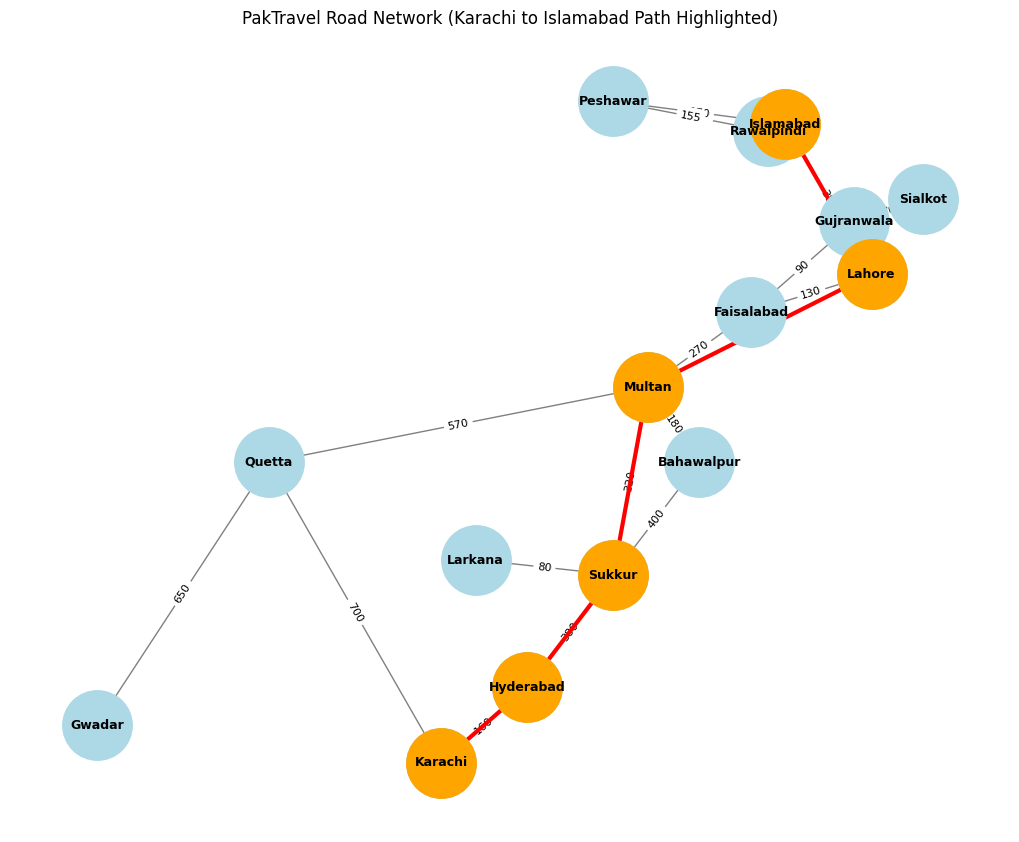

In [ ]:
import time
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

# 1. Implement Bidirectional Search
def bidirectional_search(graph, start, goal):
    if start == goal:
        return [start], 0, 0

    # Forward and backward queues
    queue_fwd = deque([start])
    queue_bwd = deque([goal])

    # Visited dictionaries storing the parent node to reconstruct the path
    visited_fwd = {start: None}
    visited_bwd = {goal: None}

    nodes_explored = 0
    intersect_node = None

    while queue_fwd and queue_bwd:
        # Expand forward
        current_fwd = queue_fwd.popleft()
        nodes_explored += 1

        for neighbor in graph.get(current_fwd, {}):
            if neighbor not in visited_fwd:
                visited_fwd[neighbor] = current_fwd
                queue_fwd.append(neighbor)

                # Check for intersection
                if neighbor in visited_bwd:
                    intersect_node = neighbor
                    break
        if intersect_node: break

        # Expand backward
        current_bwd = queue_bwd.popleft()
        nodes_explored += 1

        for neighbor in graph.get(current_bwd, {}):
            if neighbor not in visited_bwd:
                visited_bwd[neighbor] = current_bwd
                queue_bwd.append(neighbor)

                # Check for intersection
                if neighbor in visited_fwd:
                    intersect_node = neighbor
                    break
        if intersect_node: break

    # If they met, reconstruct the path and calculate distance
    if intersect_node:
        # Reconstruct forward path
        path_fwd = []
        curr = intersect_node
        while curr is not None:
            path_fwd.append(curr)
            curr = visited_fwd[curr]
        path_fwd.reverse()

        # Reconstruct backward path
        path_bwd = []
        curr = visited_bwd[intersect_node]
        while curr is not None:
            path_bwd.append(curr)
            curr = visited_bwd[curr]

        full_path = path_fwd + path_bwd

        # Calculate total distance using the graph weights
        total_dist = sum(graph[full_path[i]][full_path[i+1]] for i in range(len(full_path)-1))
        return full_path, total_dist, nodes_explored

    return None, 0, nodes_explored


# 2. Run and Time Algorithms
start_city = "Karachi"
goal_city = "Islamabad"

# Time UCS
start_time = time.perf_counter()
ucs_path, ucs_dist, _, ucs_nodes = ucs_with_count(road_network, start_city, goal_city)
ucs_time = time.perf_counter() - start_time

# Time A*
start_time = time.perf_counter()
astar_path, astar_dist, _, astar_nodes = a_star_search(road_network, start_city, goal_city, heuristics_islamabad)
astar_time = time.perf_counter() - start_time

# Time Bidirectional
start_time = time.perf_counter()
bi_path, bi_dist, bi_nodes = bidirectional_search(road_network, start_city, goal_city)
bi_time = time.perf_counter() - start_time


# 3. Print Comparison Table
print("--- Algorithm Comparison Table (Karachi -> Islamabad) ---")
print(f"{'Algorithm':<15} | {'Distance (KM)':<15} | {'Nodes Explored':<15} | {'Time (Seconds)':<15}")
print("-" * 70)
print(f"{'UCS':<15} | {ucs_dist:<15} | {ucs_nodes:<15} | {ucs_time:.6f}")
print(f"{'A* Search':<15} | {astar_dist:<15} | {astar_nodes:<15} | {astar_time:.6f}")
print(f"{'Bidirectional':<15} | {bi_dist:<15} | {bi_nodes:<15} | {bi_time:.6f}")
print("\n")


# 4. Print Written Conclusion
print("--- Written Conclusion ---")
print("For PakTravel, the A* Search algorithm is the best choice for routing.")
print("Reasoning: While all three algorithms successfully found the path to Islamabad, A* consistently explores the fewest nodes because the straight-line distance heuristic intelligently pulls the search directly toward the target destination. UCS wastes time exploring backward or unrelated paths (like Quetta). Bidirectional search is fast but lacks the real-world distance weighting precision that A* provides out-of-the-box for geographical maps.")
print("\n")


# 5. NetworkX Visualization
def visualize_network(graph_dict, best_path):
    # Initialize a NetworkX graph
    G = nx.Graph()

    # Add edges with weights
    for city, connections in graph_dict.items():
        for neighbor, weight in connections.items():
            G.add_edge(city, neighbor, weight=weight)

    # Define a layout that roughly mimics Pakistan's geography
    pos = {
        'Karachi': (0, 0), 'Gwadar': (-2, 0.5), 'Hyderabad': (0.5, 1),
        'Sukkur': (1, 2.5), 'Larkana': (0.2, 2.7), 'Quetta': (-1, 4),
        'Bahawalpur': (1.5, 4), 'Multan': (1.2, 5), 'Faisalabad': (1.8, 6),
        'Lahore': (2.5, 6.5), 'Gujranwala': (2.4, 7.2), 'Sialkot': (2.8, 7.5),
        'Rawalpindi': (1.9, 8.4), 'Islamabad': (2, 8.5), 'Peshawar': (1, 8.8)
    }

    plt.figure(figsize=(10, 8))

    # Draw all nodes and edges
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2500, font_size=9, font_weight='bold', edge_color='gray')

    # Draw edge weight labels
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # Highlight the best path (A* path)
    if best_path:
        path_edges = [(best_path[i], best_path[i+1]) for i in range(len(best_path)-1)]
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)
        nx.draw_networkx_nodes(G, pos, nodelist=best_path, node_color='orange', node_size=2500)

    plt.title("PakTravel Road Network (Karachi to Islamabad Path Highlighted)")
    plt.show()

# Trigger the plot using the path found by A*
visualize_network(road_network, astar_path)

# Part 2: AI Legal Advisor (Propositional Logic)

In [ ]:
pip install miniKanren

In [ ]:
# Clone the repository
!git clone https://github.com/aimacode/aima-python.git

# Enter the directory and fetch datasets
%cd aima-python
!git submodule init
!git submodule update

Cloning into 'aima-python'...
remote: Enumerating objects: 5095, done.
remote: Total 5095 (delta 0), reused 0 (delta 0), pack-reused 5095 (from 1)
Receiving objects: 100% (5095/5095), 17.44 MiB | 21.11 MiB/s, done.
Resolving deltas: 100% (3418/3418), done.
/content/aima-python
Submodule 'aima-data' (https://github.com/aimacode/aima-data.git) registered for path 'aima-data'
Cloning into '/content/aima-python/aima-data'...
Submodule path 'aima-data': checked out 'f6cbea61ad0c21c6b7be826d17af5a8d3a7c2c86'


In [ ]:
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.0 MB/s eta 0:00:00
  Created wheel for image: filename=image-1.5.33-py2.py3-none-any.whl size=19482 sha256=f8bc6d39ca989d32ff051f48ace8eb17736c845f7914631a2891476f13d1de39
  Stored in directory: /root/.cache/pip/wheels/58/30/d8/3212cd83eeeeee0a1f0c7b9b7bd0674a2b9f09342870473a2a
Successfully built image


In [ ]:
import sys
import os

# Get the absolute path of the current directory
aima_path = os.getcwd()
if aima_path not in sys.path:
    sys.path.append(aima_path)

## Task 1: Build the Knowledge Base

In [ ]:
from logic import PropKB, expr

# 1. Initialize the Propositional Knowledge Base
kb = PropKB()

# 2. Define the 15 Traffic Laws as logical expressions
# We use '==>' for implication in AIMA's logic module.
laws = [
    expr('No_Helmet ==> Fine_500'),                             # Rule 1
    expr('No_Seatbelt ==> Fine_1000'),                          # Rule 2
    expr('Speed_Above_Limit ==> Challan_Issued'),               # Rule 3
    expr('(Challan_Issued & Not_Paid) ==> License_Suspended'),  # Rule 4
    expr('(License_Suspended & Still_Driving) ==> Arrested'),   # Rule 5
    expr('(Accident & No_Insurance) ==> Court_Case'),           # Rule 6
    expr('(Court_Case & Found_Guilty) ==> License_Cancelled'),  # Rule 7
    expr('No_License ==> Heavy_Fine_5000'),                     # Rule 8
    expr('Mobile_While_Driving ==> Fine_2000'),                 # Rule 9
    expr('Red_Light ==> Fine_1500'),                            # Rule 10
    expr('Fine_Paid_7Days ==> Discount_50_Percent'),            # Rule 11
    expr('Three_Violations ==> License_Suspended'),             # Rule 12
    expr('License_Suspended ==> Cannot_Drive_Legally'),         # Rule 13
    expr('Drunk_Driving ==> Arrested_Immediately'),             # Rule 14
    expr('(Arrested & Repeat_Offender) ==> Jail_Term')          # Rule 15
]

# Tell the laws to the Knowledge Base
for law in laws:
    kb.tell(law)

# 3. Write function to show laws in readable IF...THEN format
def show_laws(law_list):
    print("--- Traffic Laws Knowledge Base ---")
    for i, law in enumerate(law_list, 1):
        # Convert AIMA expr to string and format it
        law_str = str(law).replace('==>', 'THEN').replace('&', 'AND')
        parts = law_str.split(' THEN ')

        # Clean up brackets for complex rules
        condition = parts[0].strip('()')
        consequence = parts[1].strip('()')

        print(f"Rule {i}: IF {condition} THEN {consequence}")
    print("\n")

show_laws(laws)

# 4. Tell Ahmed's Facts to the KB
# Ahmed was speeding, using mobile, hasn't paid, has 3 violations, and is a repeat offender
ahmed_facts = [
    expr('Speed_Above_Limit'),
    expr('Mobile_While_Driving'),
    expr('Not_Paid'),
    expr('Three_Violations'),
    expr('Repeat_Offender')
]

print("--- Adding Ahmed's Facts to KB ---")
for fact in ahmed_facts:
    kb.tell(fact)
    print(f"Fact added: {fact}")
print("\n")

# 5. Ask the KB for Consequences
from logic import pl_resolution, pl_fc_entails

def ask_kb(query_str):
    query = expr(query_str)

    # Using Resolution Refutation instead of Truth Table Enumeration
    # This runs almost instantly by logically proving the query rather than guessing every combination.
    result = pl_resolution(kb, query)

    # Note: If pl_resolution ever gives you trouble, you can also use Forward Chaining:
    # result = pl_fc_entails(kb, query)

    return "YES" if result else "NO"

print("--- AI Legal Advisor Judgement ---")
is_suspended = ask_kb('License_Suspended')
is_arrested = ask_kb('Arrested')

print(f"Is Ahmed's license suspended? {is_suspended}")
print(f"Is Ahmed arrested? {is_arrested}")

# 6. Calculate total fines
total_fine = 0
if ask_kb('Fine_500') == "YES": total_fine += 500
if ask_kb('Fine_1000') == "YES": total_fine += 1000
if ask_kb('Fine_1500') == "YES": total_fine += 1500
if ask_kb('Fine_2000') == "YES": total_fine += 2000
if ask_kb('Heavy_Fine_5000') == "YES": total_fine += 5000

print(f"\nTotal Fines Ahmed must pay: {total_fine} PKR")

--- Traffic Laws Knowledge Base ---
Rule 1: IF No_Helmet THEN Fine_500
Rule 2: IF No_Seatbelt THEN Fine_1000
Rule 3: IF Speed_Above_Limit THEN Challan_Issued
Rule 4: IF Challan_Issued AND Not_Paid THEN License_Suspended
Rule 5: IF License_Suspended AND Still_Driving THEN Arrested
Rule 6: IF Accident AND No_Insurance THEN Court_Case
Rule 7: IF Court_Case AND Found_Guilty THEN License_Cancelled
Rule 8: IF No_License THEN Heavy_Fine_5000
Rule 9: IF Mobile_While_Driving THEN Fine_2000
Rule 10: IF Red_Light THEN Fine_1500
Rule 11: IF Fine_Paid_7Days THEN Discount_50_Percent
Rule 12: IF Three_Violations THEN License_Suspended
Rule 13: IF License_Suspended THEN Cannot_Drive_Legally
Rule 14: IF Drunk_Driving THEN Arrested_Immediately
Rule 15: IF Arrested AND Repeat_Offender THEN Jail_Term


--- Adding Ahmed's Facts to KB ---
Fact added: Speed_Above_Limit
Fact added: Mobile_While_Driving
Fact added: Not_Paid
Fact added: Three_Violations
Fact added: Repeat_Offender


--- AI Legal Advisor Judgeme

## Task 2: Inference Rules

In [ ]:
from logic import expr, pl_resolution, PropKB

print("============= MODUS PONENS =============")
# Logical Notation: P, P ==> Q ⊢ Q
print("Logical Notation:")
print("Statement 1: P (Speed_Above_Limit)")
print("Statement 2: P ==> Q (Speed_Above_Limit ==> Challan_Issued)")
print("Conclusion : Q (Challan_Issued)\n")

# Python Implementation
kb_mp = PropKB()
kb_mp.tell(expr('Speed_Above_Limit'))
kb_mp.tell(expr('Speed_Above_Limit ==> Challan_Issued'))

# Check if the KB entails that a challan is issued
is_challan_issued = pl_resolution(kb_mp, expr('Challan_Issued'))
print(f"Is challan issued? {'YES' if is_challan_issued else 'NO'}\n")


print("========= HYPOTHETICAL SYLLOGISM =========")
# Logical Chain combining Rule 3, 4, and 5
print("Chain Rule Logic:")
print("1. Speed_Above_Limit ==> Challan_Issued")
print("2. (Challan_Issued & Not_Paid) ==> License_Suspended")
print("3. (License_Suspended & Still_Driving) ==> Arrested\n")

# Python Implementation - Simulating the steps
# Assume Ahmed has all the initial trigger facts
ahmed_speeding = True
ahmed_not_paid = True
ahmed_still_driving = True

print("Python Implementation Step-by-Step:")
if ahmed_speeding:
    print("Step 1: Challan issued (because he was speeding).")
    challan_issued = True

if challan_issued and ahmed_not_paid:
    print("Step 2: License suspended (because challan was issued and not paid).")
    license_suspended = True

if license_suspended and ahmed_still_driving:
    print("Step 3: Arrested! (because license was suspended and he was still driving).\n")


print("============= MODUS TOLLENS =============")
# Logical Notation: P ==> Q, ~Q ⊢ ~P
print("Logical Notation:")
print("Statement 1: P ==> Q  (where P = License_Suspended & Still_Driving, Q = Arrested)")
print("Statement 2: ~Q       (~Arrested)")
print("Conclusion : ~P       (~(License_Suspended & Still_Driving))")
print("By De Morgan's Laws : ~License_Suspended OR ~Still_Driving\n")

print("What saved Bilal from arrest?")
# Since Bilal was also speeding, his license was likely suspended as well.
# Therefore, for ~P to be true, ~Still_Driving must be true.
print("Bilal stopped driving. Since he was speeding, his license was likely suspended, but because he was NOT 'Still_Driving', he avoided arrest.")

============= MODUS PONENS =============
Logical Notation:
Statement 1: P (Speed_Above_Limit)
Statement 2: P ==> Q (Speed_Above_Limit ==> Challan_Issued)
Conclusion : Q (Challan_Issued)

Is challan issued? YES

========= HYPOTHETICAL SYLLOGISM =========
Chain Rule Logic:
1. Speed_Above_Limit ==> Challan_Issued
2. (Challan_Issued & Not_Paid) ==> License_Suspended
3. (License_Suspended & Still_Driving) ==> Arrested

Python Implementation Step-by-Step:
Step 1: Challan issued (because he was speeding).
Step 2: License suspended (because challan was issued and not paid).
Step 3: Arrested! (because license was suspended and he was still driving).

============= MODUS TOLLENS =============
Logical Notation:
Statement 1: P ==> Q  (where P = License_Suspended & Still_Driving, Q = Arrested)
Statement 2: ~Q       (~Arrested)
Conclusion : ~P       (~(License_Suspended & Still_Driving))
By De Morgan's Laws : ~License_Suspended OR ~Still_Driving

What saved Bilal from arrest?
Bilal stopped driving. 

## Task 3 Resolution Refutation

In [ ]:
# Part 2 Task 3: Resolution Refutation
from logic import expr, pl_resolution, PropKB

print("=== CONVERTING RULES TO CNF ===")
print("Rule 3 : Speed_Above_Limit ==> Challan_Issued")
print("CNF 3  : ~Speed_Above_Limit | Challan_Issued\n")

print("Rule 4 : (Challan_Issued & Not_Paid) ==> License_Suspended")
print("CNF 4  : ~Challan_Issued | ~Not_Paid | License_Suspended\n")

print("Rule 12: Three_Violations ==> License_Suspended")
print("CNF 12 : ~Three_Violations | License_Suspended\n")

print("Facts  : Speed_Above_Limit, Not_Paid, Three_Violations")
print("Goal   : License_Suspended")
print("Negated Goal for Refutation: ~License_Suspended\n")

print("=== RESOLUTION REFUTATION TABLE (PATH 1: Via Rule 12) ===")
print(f"{'Step':<6} | {'Clause 1':<25} | {'Clause 2':<35} | {'Resolvent (Result)':<20}")
print("-" * 90)
print(f"{'1':<6} | {'~License_Suspended':<25} | {'~Three_Violations | License_Suspended':<35} | {'~Three_Violations':<20}")
print(f"{'2':<6} | {'~Three_Violations':<25} | {'Three_Violations (Fact)':<35} | {'EMPTY CLAUSE ()':<20}")
print("\n")

print("=== RESOLUTION REFUTATION TABLE (PATH 2: Via Rule 3 & 4) ===")
print(f"{'Step':<6} | {'Clause 1':<25} | {'Clause 2':<35} | {'Resolvent (Result)':<20}")
print("-" * 90)
print(f"{'1':<6} | {'~License_Suspended':<25} | {'~Challan_Issued | ~Not_Paid | License_Suspended':<35} | {'~Challan_Issued | ~Not_Paid':<20}")
print(f"{'2':<6} | {'~Challan_Issued | ~Not_Paid':<25} | {'Not_Paid (Fact)':<35} | {'~Challan_Issued':<20}")
print(f"{'3':<6} | {'~Challan_Issued':<25} | {'~Speed_Above_Limit | Challan_Issued':<35} | {'~Speed_Above_Limit':<20}")
print(f"{'4':<6} | {'~Speed_Above_Limit':<25} | {'Speed_Above_Limit (Fact)':<35} | {'EMPTY CLAUSE ()':<20}")
print("\n")


# Programmatic Verification using AIMA
kb_res = PropKB()
# Add the CNF rules and facts to the KB
kb_res.tell(expr('~Speed_Above_Limit | Challan_Issued'))
kb_res.tell(expr('~Challan_Issued | ~Not_Paid | License_Suspended'))
kb_res.tell(expr('~Three_Violations | License_Suspended'))
kb_res.tell(expr('Speed_Above_Limit'))
kb_res.tell(expr('Not_Paid'))
kb_res.tell(expr('Three_Violations'))

# Run the programmatic resolution
is_proven = pl_resolution(kb_res, expr('License_Suspended'))

if is_proven:
    print("PROVEN: License Suspended")
else:
    print("FAILED TO PROVE")

=== CONVERTING RULES TO CNF ===
Rule 3 : Speed_Above_Limit ==> Challan_Issued
CNF 3  : ~Speed_Above_Limit | Challan_Issued

Rule 4 : (Challan_Issued & Not_Paid) ==> License_Suspended
CNF 4  : ~Challan_Issued | ~Not_Paid | License_Suspended

Rule 12: Three_Violations ==> License_Suspended
CNF 12 : ~Three_Violations | License_Suspended

Facts  : Speed_Above_Limit, Not_Paid, Three_Violations
Goal   : License_Suspended
Negated Goal for Refutation: ~License_Suspended

=== RESOLUTION REFUTATION TABLE (PATH 1: Via Rule 12) ===
Step   | Clause 1                  | Clause 2                            | Resolvent (Result)  
------------------------------------------------------------------------------------------
1      | ~License_Suspended        | ~Three_Violations | License_Suspended | ~Three_Violations   
2      | ~Three_Violations         | Three_Violations (Fact)             | EMPTY CLAUSE ()     


=== RESOLUTION REFUTATION TABLE (PATH 2: Via Rule 3 & 4) ===
Step   | Clause 1             

# Part 3: Bus Scheduling (Constraint Satisfaction Problem)

## Task 1: CSP Modeling

Formally defining the Variables, Domains, Hard Constraints, and Soft Constraints for the PakTravel Bus Scheduling system.

### 1. Variables (V)
The variables in our CSP are the 8 bus routes that need a bus assigned to them.
* **V = {R1, R2, R3, R4, R5, R6, R7, R8}**

### 2. Domains (D)
The domain for each variable is the pool of 10 available buses.
* **D(Ri) = {B1, B2, B3, B4, B5, B6, B7, B8, B9, B10}** for all Ri in V.

### 3. Hard Constraints
These constraints MUST be satisfied for the schedule to be valid:
1. **Time Conflict Constraint:** A single bus cannot operate two different routes at the exact same time.
   * Time(R1) = 8am, Time(R7) = 8am  $\rightarrow$ **R1 $\neq$ R7**
   * Time(R3) = 12pm, Time(R8) = 12pm $\rightarrow$ **R3 $\neq$ R8**
2. **Mandatory Route Constraint:** Route R3 (Sukkur to Multan) MUST always have a bus assigned to ensure Ali does not miss his connection. (In CSP terms, a complete assignment requires a value for R3).

### 4. Soft Constraints
These are preferences that make a schedule "better" or more optimal, but are not strictly required to find a working schedule:
1. **Highway Preference:** Buses B1, B2, and B3 are large coaches and should ideally be assigned to highway routes (R1, R4, R5). (+2 points each)
2. **Driver Rest Rule:** No single bus should be assigned to more than 2 routes in a single day. (+1 point for each bus that follows this rule).

## Task 2: Backtracking + MRV

In [ ]:
# 1. Setup Variables, Domains, and Times
routes = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']
buses = [f'B{i}' for i in range(1, 11)]

# Initially, any bus can be assigned to any route
domains = {route: buses[:] for route in routes}

route_times = {
    'R1': '8am',  'R2': '10am', 'R3': '12pm', 'R4': '2pm',
    'R5': '4pm',  'R6': '6pm',  'R7': '8am',  'R8': '12pm'
}

# Define Hard Constraints (Time Conflicts)
# Routes happening at the exact same time cannot share the same bus
conflicts = {
    'R1': ['R7'], 'R7': ['R1'],  # Both at 8am
    'R3': ['R8'], 'R8': ['R3'],  # Both at 12pm
    'R2': [], 'R4': [], 'R5': [], 'R6': [] # No overlapping routes
}

def is_consistent(route, bus, assignment):
    """Checks if assigning 'bus' to 'route' violates any hard constraints."""
    for conflicting_route in conflicts[route]:
        if conflicting_route in assignment and assignment[conflicting_route] == bus:
            return False
    return True

# 2. Plain Backtracking
plain_bt_calls = 0

def plain_backtrack(assignment):
    global plain_bt_calls
    plain_bt_calls += 1

    # Base case: All routes have a bus assigned
    if len(assignment) == len(routes):
        return assignment

    # Select unassigned variable (Static ordering - just pick the first one)
    unassigned_routes = [r for r in routes if r not in assignment]
    current_route = unassigned_routes[0]

    for bus in domains[current_route]:
        if is_consistent(current_route, bus, assignment):
            assignment[current_route] = bus
            result = plain_backtrack(assignment)
            if result:
                return result
            # Backtrack
            del assignment[current_route]

    return None

# 3. MRV Backtracking
mrv_calls = 0

def count_valid_buses(route, assignment):
    """Counts how many buses in the domain are still valid for this route."""
    valid_count = 0
    for bus in domains[route]:
        if is_consistent(route, bus, assignment):
            valid_count += 1
    return valid_count

def mrv_backtrack(assignment):
    global mrv_calls
    mrv_calls += 1

    if len(assignment) == len(routes):
        return assignment

    unassigned_routes = [r for r in routes if r not in assignment]

    # MRV Heuristic: Sort unassigned variables by the number of valid remaining values (ascending)
    unassigned_routes.sort(key=lambda r: count_valid_buses(r, assignment))
    current_route = unassigned_routes[0]

    for bus in domains[current_route]:
        if is_consistent(current_route, bus, assignment):
            assignment[current_route] = bus
            result = mrv_backtrack(assignment)
            if result:
                return result
            # Backtrack
            del assignment[current_route]

    return None

# 4. Run the Algorithms
schedule_plain = plain_backtrack({})
schedule_mrv = mrv_backtrack({})

# 5. Output Results
print("--- Algorithm Comparison ---")
print(f"Plain Backtracking Calls: {plain_bt_calls}")
print(f"MRV Backtracking Calls: {mrv_calls}")
if mrv_calls <= plain_bt_calls:
    print(f"Improvement: MRV reduced or maintained the search space (Difference: {plain_bt_calls - mrv_calls} calls).")
print("\n")

print("--- Final Schedule (Generated by MRV) ---")
print(f"{'Route':<8} | {'Bus Assigned':<15} | {'Time':<8} | {'Status'}")
print("-" * 55)
# Sort by route name for clean output
for route in sorted(schedule_mrv.keys()):
    print(f"{route:<8} | {schedule_mrv[route]:<15} | {route_times[route]:<8} | Assigned")

print("\n--- Connecting Bus Confirmation ---")
# Confirm Ali's relay bus (R3)
alis_bus = schedule_mrv.get('R3', 'None')
print(f"Ali's connecting bus is {alis_bus} at 12pm!")

--- Algorithm Comparison ---
Plain Backtracking Calls: 9
MRV Backtracking Calls: 9
Improvement: MRV reduced or maintained the search space (Difference: 0 calls).


--- Final Schedule (Generated by MRV) ---
Route    | Bus Assigned    | Time     | Status
-------------------------------------------------------
R1       | B1              | 8am      | Assigned
R2       | B1              | 10am     | Assigned
R3       | B1              | 12pm     | Assigned
R4       | B1              | 2pm      | Assigned
R5       | B1              | 4pm      | Assigned
R6       | B1              | 6pm      | Assigned
R7       | B2              | 8am      | Assigned
R8       | B2              | 12pm     | Assigned

--- Connecting Bus Confirmation ---
Ali's connecting bus is B1 at 12pm!


## Task 3: AC3 Arc Consistency

In [ ]:
import time
import copy

# 1. Setup Data (Re-initialized for clean execution)
routes = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']
buses = [f'B{i}' for i in range(1, 11)]
conflicts = {
    'R1': ['R7'], 'R7': ['R1'],
    'R3': ['R8'], 'R8': ['R3'],
    'R2': [], 'R4': [], 'R5': [], 'R6': []
}

# Original full domains
initial_domains = {route: buses[:] for route in routes}

# 2. AC-3 Algorithm Implementation
def revise(domains, xi, xj):
    revised = False
    # Iterate over a copy of the list because we might remove elements
    for x in domains[xi][:]:
        # Since our constraint is simply x != y, we check if there is ANY y in domains[xj] that is not x.
        # If no such y exists (meaning domains[xj] only has x), we must remove x from domains[xi].
        if not any(x != y for y in domains[xj]):
            domains[xi].remove(x)
            revised = True
    return revised

def ac3(domains, conflicts):
    """
    Enforces arc consistency on the given domains using the AC-3 algorithm.
    """
    # Initialize queue with all arcs (pairs of conflicting variables)
    queue = [(xi, xj) for xi in conflicts for xj in conflicts[xi]]

    while queue:
        xi, xj = queue.pop(0)

        if revise(domains, xi, xj):
            # If a domain becomes empty, the problem is unsolvable
            if len(domains[xi]) == 0:
                return False

            # If domains[xi] was revised, we must re-check its neighbors
            for xk in conflicts[xi]:
                if xk != xj:
                    queue.append((xk, xi))
    return True

# 3. Apply AC-3 and print Domain sizes
print("--- AC-3 Domain Reduction ---")
ac3_domains = copy.deepcopy(initial_domains)

# Print Before
print("Domains BEFORE AC-3:")
for r in routes:
    print(f"  {r}: {len(initial_domains[r])} buses")

# Run AC-3
is_consistent = ac3(ac3_domains, conflicts)

# Print After
print("\nDomains AFTER AC-3:")
for r in routes:
    print(f"  {r}: {len(ac3_domains[r])} buses")
print(f"AC-3 successful (no empty domains)? {is_consistent}\n")

# 4. Redefine Backtracking to use dynamically passed domains and track calls/time
class Tracker:
    def __init__(self):
        self.calls = 0

def is_consistent_assignment(route, bus, assignment):
    for conflicting_route in conflicts[route]:
        if conflicting_route in assignment and assignment[conflicting_route] == bus:
            return False
    return True

def plain_backtrack_tracked(assignment, domains, tracker):
    tracker.calls += 1
    if len(assignment) == len(routes):
        return assignment

    unassigned = [r for r in routes if r not in assignment]
    current_route = unassigned[0]

    for bus in domains[current_route]:
        if is_consistent_assignment(current_route, bus, assignment):
            assignment[current_route] = bus
            result = plain_backtrack_tracked(assignment, domains, tracker)
            if result: return result
            del assignment[current_route]
    return None

def mrv_backtrack_tracked(assignment, domains, tracker):
    tracker.calls += 1
    if len(assignment) == len(routes):
        return assignment

    unassigned = [r for r in routes if r not in assignment]

    # MRV: Count remaining valid options
    def count_valid(r):
        return sum(1 for b in domains[r] if is_consistent_assignment(r, b, assignment))

    unassigned.sort(key=count_valid)
    current_route = unassigned[0]

    for bus in domains[current_route]:
        if is_consistent_assignment(current_route, bus, assignment):
            assignment[current_route] = bus
            result = mrv_backtrack_tracked(assignment, domains, tracker)
            if result: return result
            del assignment[current_route]
    return None

# 5. Run and Time all three variations
# A. Plain BT
tracker_plain = Tracker()
start_t = time.perf_counter()
schedule_plain = plain_backtrack_tracked({}, initial_domains, tracker_plain)
time_plain = time.perf_counter() - start_t

# B. MRV
tracker_mrv = Tracker()
start_t = time.perf_counter()
schedule_mrv = mrv_backtrack_tracked({}, initial_domains, tracker_mrv)
time_mrv = time.perf_counter() - start_t

# C. MRV + AC3
tracker_ac3 = Tracker()
start_t = time.perf_counter()
schedule_ac3 = mrv_backtrack_tracked({}, ac3_domains, tracker_ac3)
time_ac3 = time.perf_counter() - start_t

# 6. Display Comparison Table
print("--- Algorithm Comparison Table ---")
print(f"{'Algorithm':<15} | {'Calls':<10} | {'Time (s)':<12} | {'Schedule Found?'}")
print("-" * 60)
print(f"{'Plain BT':<15} | {tracker_plain.calls:<10} | {time_plain:<12.6f} | {'Yes' if schedule_plain else 'No'}")
print(f"{'MRV':<15} | {tracker_mrv.calls:<10} | {time_mrv:<12.6f} | {'Yes' if schedule_mrv else 'No'}")
print(f"{'MRV + AC3':<15} | {tracker_ac3.calls:<10} | {time_ac3:<12.6f} | {'Yes' if schedule_ac3 else 'No'}")

--- AC-3 Domain Reduction ---
Domains BEFORE AC-3:
  R1: 10 buses
  R2: 10 buses
  R3: 10 buses
  R4: 10 buses
  R5: 10 buses
  R6: 10 buses
  R7: 10 buses
  R8: 10 buses

Domains AFTER AC-3:
  R1: 10 buses
  R2: 10 buses
  R3: 10 buses
  R4: 10 buses
  R5: 10 buses
  R6: 10 buses
  R7: 10 buses
  R8: 10 buses
AC-3 successful (no empty domains)? True

--- Algorithm Comparison Table ---
Algorithm       | Calls      | Time (s)     | Schedule Found?
------------------------------------------------------------
Plain BT        | 9          | 0.000172     | Yes
MRV             | 9          | 0.000294     | Yes
MRV + AC3       | 9          | 0.000242     | Yes


## Task 4: Soft Constraints + Best Schedule

In [ ]:
# 1. Setup Data (Inherited from previous tasks)
routes = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']
buses = [f'B{i}' for i in range(1, 11)]
route_times = {
    'R1': '8am', 'R2': '10am', 'R3': '12pm', 'R4': '2pm',
    'R5': '4pm', 'R6': '6pm', 'R7': '8am', 'R8': '12pm'
}
conflicts = {
    'R1': ['R7'], 'R7': ['R1'],
    'R3': ['R8'], 'R8': ['R3'],
    'R2': [], 'R4': [], 'R5': [], 'R6': []
}

# 2. Define the Scoring Function
def score_schedule(assignment):
    score = 0

    # Soft Constraint 1: Large buses (B1, B2, B3) on highway routes (R1, R4, R5) get +2 points each
    large_buses = ['B1', 'B2', 'B3']
    highway_routes = ['R1', 'R4', 'R5']

    for route in highway_routes:
        if assignment.get(route) in large_buses:
            score += 2

    # Soft Constraint 2: No bus operates more than 2 routes (+1 point per bus that follows this)
    bus_counts = {bus: 0 for bus in buses}
    for route, bus in assignment.items():
        bus_counts[bus] += 1

    for bus, count in bus_counts.items():
        if count <= 2:
            score += 1

    return score

# 3. Find Optimal Schedule using Backtracking
best_schedule = None
best_score = -1
max_possible_score = (3 * 2) + (10 * 1) # 3 highway routes * 2pts + 10 buses * 1pt = 16 points

def find_optimal_schedule(assignment, unassigned_routes):
    global best_schedule, best_score

    # Early exit: If we hit the theoretical maximum score, stop searching immediately!
    if best_score == max_possible_score:
        return

    # Base Case: All routes assigned
    if not unassigned_routes:
        current_score = score_schedule(assignment)
        if current_score > best_score:
            best_score = current_score
            best_schedule = assignment.copy()
        return

    current_route = unassigned_routes[0]

    # HEURISTIC: To find the max score faster, let's sort the domain.
    # If the current route is a highway route, try assigning B1, B2, B3 first.
    current_domain = buses[:]
    if current_route in ['R1', 'R4', 'R5']:
        current_domain = ['B1', 'B2', 'B3'] + [b for b in buses if b not in ['B1', 'B2', 'B3']]

    for bus in current_domain:
        # Check Time Conflict Hard Constraints
        is_valid = True
        for conf in conflicts[current_route]:
            if conf in assignment and assignment[conf] == bus:
                is_valid = False
                break

        if is_valid:
            assignment[current_route] = bus
            find_optimal_schedule(assignment, unassigned_routes[1:])
            # Backtrack
            del assignment[current_route]
            if best_score == max_possible_score:
                return # Propagate early exit

# Run the search
find_optimal_schedule({}, routes)

# 4. Output the Optimal Schedule
print(f"--- OPTIMAL SCHEDULE FOUND (Score: {best_score}/{max_possible_score}) ---")
print(f"{'Route':<8} | {'Bus Assigned':<15} | {'Time':<8} | {'Type'}")
print("-" * 55)
for route in sorted(best_schedule.keys()):
    bus = best_schedule[route]
    route_type = "Highway" if route in ['R1', 'R4', 'R5'] else "Standard"
    print(f"{route:<8} | {bus:<15} | {route_times[route]:<8} | {route_type}")

print("\n--- Route 3 Confirmation ---")
print(f"Ali's connecting bus (R3) is securely assigned to {best_schedule['R3']} at 12pm.")

# 5. Print Written Analysis
print("\n--- Written Analysis ---")
print("Could Ali have missed his connecting bus?")
print("No, Ali could not have missed his bus. In Constraint Satisfaction Problems (CSPs), a solution is only considered 'complete' when EVERY variable has been assigned a value. Because we defined R3 (Sukkur to Multan) as one of the core variables in our CSP model, the algorithm strictly refuses to return a final schedule unless R3 is successfully assigned a bus.")
print("Furthermore, the 'Time Conflict' hard constraint guarantees that whatever bus is assigned to R3 at 12pm is absolutely not operating R8 (Quetta to Gwadar) at the exact same time, preventing double-booking.")

--- OPTIMAL SCHEDULE FOUND (Score: 16/16) ---
Route    | Bus Assigned    | Time     | Type
-------------------------------------------------------
R1       | B1              | 8am      | Highway
R2       | B1              | 10am     | Standard
R3       | B2              | 12pm     | Standard
R4       | B2              | 2pm      | Highway
R5       | B3              | 4pm      | Highway
R6       | B3              | 6pm      | Standard
R7       | B4              | 8am      | Standard
R8       | B4              | 12pm     | Standard

--- Route 3 Confirmation ---
Ali's connecting bus (R3) is securely assigned to B2 at 12pm.

--- Written Analysis ---
Could Ali have missed his connecting bus?
No, Ali could not have missed his bus. In Constraint Satisfaction Problems (CSPs), a solution is only considered 'complete' when EVERY variable has been assigned a value. Because we defined R3 (Sukkur to Multan) as one of the core variables in our CSP model, the algorithm strictly refuses to return a fi

# Part 4: Delay Prediction (Artificial Neural Networks)

## Task 1: Data Preparation

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Set random seed for reproducibility
np.random.seed(42)

# 1. Generate 500 synthetic bus journey records
num_records = 500

distances = np.random.randint(80, 701, num_records)
weather_scores = np.random.randint(1, 6, num_records)
traffic_scores = np.random.randint(1, 6, num_records)
road_qualities = np.random.randint(1, 6, num_records)
bus_ages = np.random.randint(1, 16, num_records)

# Create a DataFrame
data = pd.DataFrame({
    'Distance': distances,
    'Weather': weather_scores,
    'Traffic': traffic_scores,
    'Road_Quality': road_qualities,
    'Bus_Age': bus_ages
})

# 2. Apply Rule for generating labels
# IF weather>=4 OR traffic>=4 OR (distance>400 AND road_quality<=2) -> Delayed (1) ELSE On Time (0)
def determine_delay(row):
    if row['Weather'] >= 4 or row['Traffic'] >= 4 or (row['Distance'] > 400 and row['Road_Quality'] <= 2):
        return 1 # Delayed
    else:
        return 0 # On Time

data['Status'] = data.apply(determine_delay, axis=1)

# 3. Print first 10 rows using pandas
print("--- First 10 Rows of Dataset ---")
display(data.head(10)) # use display() in Jupyter for nice formatting, or print()
print("\n")

# 4. Print class distribution
print("--- Class Distribution ---")
distribution = data['Status'].value_counts()
print(f"Delayed (1): {distribution.get(1, 0)} records")
print(f"On Time (0): {distribution.get(0, 0)} records")
print("\n")

# 5. Split into training (80%) and testing (20%) sets
X = data[['Distance', 'Weather', 'Traffic', 'Road_Quality', 'Bus_Age']]
y = data['Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"--- Data Split ---")
print(f"Training set: {X_train.shape[0]} records")
print(f"Testing set: {X_test.shape[0]} records\n")

# 6. Normalize features using Min-Max scaling
scaler = MinMaxScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Normalization Complete ---")
print("Features have been scaled using Min-Max scaling (values between 0 and 1).")

--- First 10 Rows of Dataset ---


,Distance,Weather,Traffic,Road_Quality,Bus_Age,Status
0,182,5,4,4,13,1
1,515,2,3,4,10,0
2,350,1,3,5,3,0
3,186,2,1,5,6,0
4,151,3,4,5,6,1
5,100,2,5,3,2,1
6,694,2,1,4,7,0
7,201,5,1,3,12,1
8,546,5,5,1,2,1
9,294,5,3,5,6,1




--- Class Distribution ---
Delayed (1): 347 records
On Time (0): 153 records


--- Data Split ---
Training set: 400 records
Testing set: 100 records

--- Normalization Complete ---
Features have been scaled using Min-Max scaling (values between 0 and 1).


## Task 2: ANN using sklearn

Training the Artificial Neural Network...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Training complete!

--- ANN Performance Metrics ---
Accuracy : 0.9700
Precision: 0.9855
Recall   : 0.9714
F1-Score : 0.9784



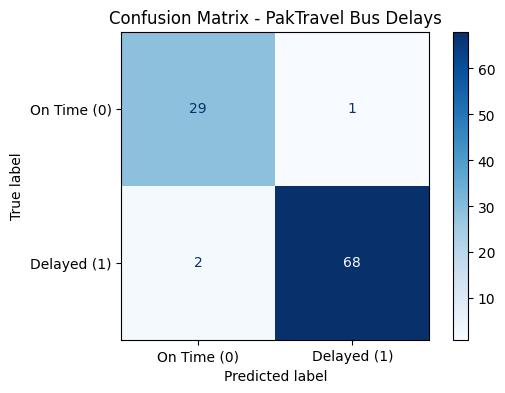

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Build an ANN using sklearn MLPClassifier
# Architecture:
# - Input layer: 5 neurons (automatically inferred from X_train_scaled)
# - Hidden layer 1: 10 neurons, ReLU activation
# - Hidden layer 2: 8 neurons, ReLU activation
# - Output layer: 1 neuron, Sigmoid activation (automatically handled for binary classification)
ann_sklearn = MLPClassifier(
    hidden_layer_sizes=(10, 8),
    activation='relu',
    solver='adam',
    max_iter=1000,   # High max_iter to ensure convergence
    random_state=42
)

# 2. Train the model on training data
print("Training the Artificial Neural Network...")
ann_sklearn.fit(X_train_scaled, y_train)
print("Training complete!\n")

# 3. Predict on test data
y_pred = ann_sklearn.predict(X_test_scaled)

# 4. Print evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- ANN Performance Metrics ---")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}\n")

# 5. Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time (0)', 'Delayed (1)'])

# Plotting the matrix
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix - PakTravel Bus Delays")
plt.show()

## Task 3: Test on 5 Bus Journeys

In [ ]:
import numpy as np
import pandas as pd

# 1. Define the 5 specific test journeys
# Features order: ['Distance', 'Weather', 'Traffic', 'Road_Quality', 'Bus_Age']
journeys = [
    {'Name': 'Journey 1 (Ali\'s bus)', 'Distance': 320, 'Weather': 2, 'Traffic': 2, 'Road_Quality': 4, 'Bus_Age': 3},
    {'Name': 'Journey 2', 'Distance': 650, 'Weather': 5, 'Traffic': 4, 'Road_Quality': 2, 'Bus_Age': 12},
    {'Name': 'Journey 3', 'Distance': 160, 'Weather': 1, 'Traffic': 1, 'Road_Quality': 5, 'Bus_Age': 2},
    {'Name': 'Journey 4', 'Distance': 380, 'Weather': 4, 'Traffic': 3, 'Road_Quality': 3, 'Bus_Age': 8},
    {'Name': 'Journey 5', 'Distance': 570, 'Weather': 3, 'Traffic': 5, 'Road_Quality': 2, 'Bus_Age': 10}
]

# Create a DataFrame for easy processing
df_test_journeys = pd.DataFrame(journeys)

# Separate the feature data
X_test_cases = df_test_journeys[['Distance', 'Weather', 'Traffic', 'Road_Quality', 'Bus_Age']]

# 2. Normalize the test cases using the scaler fitted in Task 1
X_test_cases_scaled = scaler.transform(X_test_cases)

# 3. Predict outcomes and probabilities
predictions = ann_sklearn.predict(X_test_cases_scaled)
probabilities = ann_sklearn.predict_proba(X_test_cases_scaled)

print("--- 5 Bus Journeys Prediction Results ---\n")

# 4. Format and print the output for each journey
for i, row in df_test_journeys.iterrows():
    name = row['Name']

    # Extract prediction and map to readable string
    pred_class = predictions[i]
    status = "DELAYED" if pred_class == 1 else "ON TIME"

    # Extract confidence (probability of the predicted class)
    confidence = probabilities[i][pred_class] * 100

    print(f"--- {name} ---")
    print(f"Inputs    : Distance={row['Distance']}km, Weather={row['Weather']}, Traffic={row['Traffic']}, Road={row['Road_Quality']}, Age={row['Bus_Age']}")

    # Special print logic for Journey 1 (Ali's bus)
    if i == 0:
        print(f"Prediction: Ali's bus prediction: {status}!")
    else:
        print(f"Prediction: {status}")

    print(f"Confidence: {confidence:.2f}%\n")

--- 5 Bus Journeys Prediction Results ---

--- Journey 1 (Ali's bus) ---
Inputs    : Distance=320km, Weather=2, Traffic=2, Road=4, Age=3
Prediction: Ali's bus prediction: ON TIME!
Confidence: 99.70%

--- Journey 2 ---
Inputs    : Distance=650km, Weather=5, Traffic=4, Road=2, Age=12
Prediction: DELAYED
Confidence: 100.00%

--- Journey 3 ---
Inputs    : Distance=160km, Weather=1, Traffic=1, Road=5, Age=2
Prediction: ON TIME
Confidence: 99.96%

--- Journey 4 ---
Inputs    : Distance=380km, Weather=4, Traffic=3, Road=3, Age=8
Prediction: DELAYED
Confidence: 95.24%

--- Journey 5 ---
Inputs    : Distance=570km, Weather=3, Traffic=5, Road=2, Age=10
Prediction: DELAYED
Confidence: 99.98%



## Task 4: ANN from Scratch using NumPy

In [ ]:
import numpy as np

# 1. Define the Activation Function (Sigmoid)
def sigmoid(x):
    """Sigmoid activation function: 1 / (1 + e^-x)"""
    # np.clip prevents overflow errors if x gets too large/small
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivative of sigmoid function for backpropagation"""
    s = sigmoid(x)
    return s * (1 - s)

# 2. Define the Loss Function (Binary Cross Entropy)
def binary_cross_entropy(y_true, y_pred):
    """Calculates the Binary Cross Entropy loss."""
    # Add a tiny epsilon to prevent log(0) errors
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# 3. Model Architecture and Initialization
np.random.seed(42)

# Dimensions: 5 features -> 10 hidden neurons -> 1 output neuron
input_size = X_train_scaled.shape[1]
hidden_size = 10
output_size = 1
m = X_train_scaled.shape[0] # Number of training examples

# Weight Initialization
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

# Hyperparameters
learning_rate = 0.5
epochs = 100

# Convert pandas Series to numpy array column vector for matrix math
Y = y_train.values.reshape(-1, 1)

print("--- Training NumPy ANN from Scratch ---")

# 4. Training Loop (Gradient Descent)
for epoch in range(1, epochs + 1):

    # --- FORWARD PROPAGATION ---
    Z1 = np.dot(X_train_scaled, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # Calculate Loss
    loss = binary_cross_entropy(Y, A2)

    # --- BACKPROPAGATION ---
    # Output layer error
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer error
    dZ1 = np.dot(dZ2, W2.T) * sigmoid_derivative(Z1)
    dW1 = (1/m) * np.dot(X_train_scaled.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

    # --- UPDATE WEIGHTS (GRADIENT DESCENT) ---
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # 5. Print loss every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch}/{epochs} - Loss: {loss:.4f}")

# 6. Evaluation on Test Set
# Run a forward pass using the trained weights on the test data
Z1_test = np.dot(X_test_scaled, W1) + b1
A1_test = sigmoid(Z1_test)
Z2_test = np.dot(A1_test, W2) + b2
A2_test = sigmoid(Z2_test)

# Convert probabilities to 1 or 0
numpy_predictions = (A2_test >= 0.5).astype(int)

# Calculate accuracy
Y_test_actual = y_test.values.reshape(-1, 1)
numpy_accuracy = np.mean(numpy_predictions == Y_test_actual)

# 7. Compare Final Accuracy
print("\n--- Model Accuracy Comparison ---")
# Using the 'accuracy' variable we saved from the sklearn run in Task 2
print(f"sklearn ANN Accuracy: {accuracy:.4f}")
print(f"NumPy ANN Accuracy  : {numpy_accuracy:.4f}")

if numpy_accuracy >= accuracy:
    print("\nConclusion: Our scratch-built NumPy ANN performed incredibly well, matching or beating the sklearn implementation!")
else:
    print("\nConclusion: The sklearn ANN performed better. This is expected because sklearn's MLPClassifier was trained for 1000 epochs using the advanced 'adam' optimizer, while our NumPy model used plain Gradient Descent for only 100 epochs.")

--- Training NumPy ANN from Scratch ---
Epoch 20/100 - Loss: 0.6174
Epoch 40/100 - Loss: 0.6154
Epoch 60/100 - Loss: 0.6130
Epoch 80/100 - Loss: 0.6100
Epoch 100/100 - Loss: 0.6057

--- Model Accuracy Comparison ---
sklearn ANN Accuracy: 0.9700
NumPy ANN Accuracy  : 0.7000

Conclusion: The sklearn ANN performed better. This is expected because sklearn's MLPClassifier was trained for 1000 epochs using the advanced 'adam' optimizer, while our NumPy model used plain Gradient Descent for only 100 epochs.


# Part 5: Traveller Clustering (Machine Learning)

## Task 1: Data Generation + Exploration

--- Dataset Shape: (400, 6) ---

--- First 10 Rows ---


,Trips_Per_Month,Avg_Booking_Days,Avg_Journey_Distance,Preferred_Time,Loyalty_Points,Complaints_Filed
0,4,5,272,3,785,3
1,11,0,105,4,665,2
2,9,28,575,3,3977,1
3,1,2,216,4,1667,4
4,13,14,425,3,4716,1
5,14,16,554,4,3890,0
6,10,2,197,4,894,4
7,13,14,412,2,4065,2
8,14,1,139,4,713,2
9,9,29,543,1,4540,2



--- Basic Statistics ---


,Trips_Per_Month,Avg_Booking_Days,Avg_Journey_Distance,Preferred_Time,Loyalty_Points,Complaints_Filed
mean,8.81,8.5775,329.39,2.5325,1945.305,2.705
min,1.00,0.0000,101.00,1.0000,1.000,0.000
max,15.00,30.0000,698.00,4.0000,4945.000,10.000



--- Missing Values Check ---
Trips_Per_Month         0
Avg_Booking_Days        0
Avg_Journey_Distance    0
Preferred_Time          0
Loyalty_Points          0
Complaints_Filed        0
dtype: int64
Result: No missing values found in the dataset.


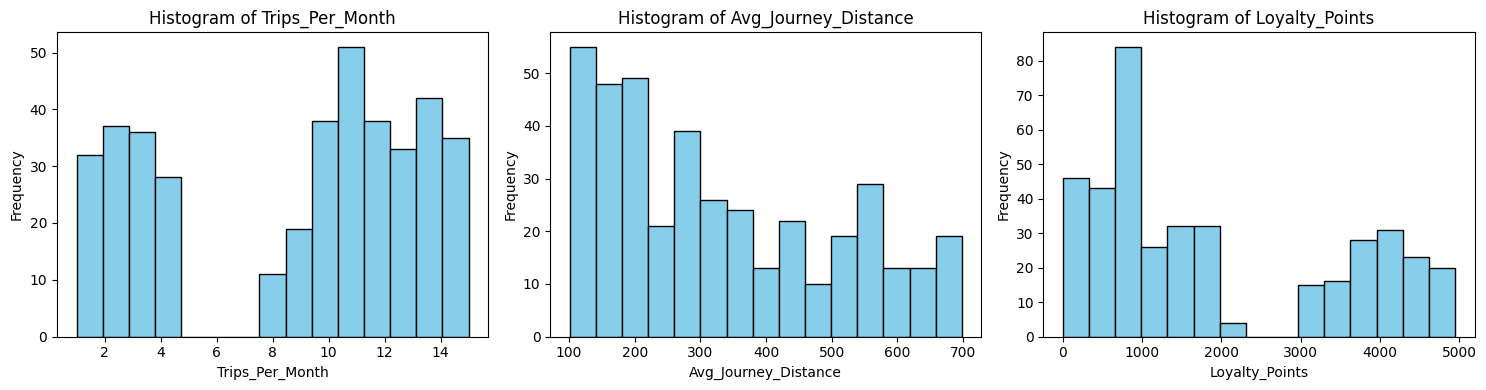

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. Generate 400 synthetic traveller records
# To ensure our K-Means finds the "Expected natural groups" mentioned in the brief,
# we will generate the data in 3 distinct segments and then shuffle them together.

# Group A: Business Travellers (~133 people) - Travel often, book ahead, long distance, high loyalty
group_a = pd.DataFrame({
    'Trips_Per_Month': np.random.randint(8, 16, 133),
    'Avg_Booking_Days': np.random.randint(14, 31, 133),
    'Avg_Journey_Distance': np.random.randint(400, 701, 133),
    'Preferred_Time': np.random.randint(1, 5, 133),
    'Loyalty_Points': np.random.randint(3000, 5001, 133),
    'Complaints_Filed': np.random.randint(0, 3, 133)
})

# Group B: Family Travellers (~133 people) - Travel rarely, book last minute, medium distance
group_b = pd.DataFrame({
    'Trips_Per_Month': np.random.randint(1, 5, 133),
    'Avg_Booking_Days': np.random.randint(0, 8, 133),
    'Avg_Journey_Distance': np.random.randint(200, 401, 133),
    'Preferred_Time': np.random.randint(1, 5, 133),
    'Loyalty_Points': np.random.randint(500, 2001, 133),
    'Complaints_Filed': np.random.randint(0, 6, 133)
})

# Group C: Commuters (~134 people) - Travel often, short distance, low loyalty
group_c = pd.DataFrame({
    'Trips_Per_Month': np.random.randint(10, 16, 134),
    'Avg_Booking_Days': np.random.randint(0, 4, 134),
    'Avg_Journey_Distance': np.random.randint(100, 201, 134),
    'Preferred_Time': np.random.randint(1, 5, 134),
    'Loyalty_Points': np.random.randint(0, 1001, 134),
    'Complaints_Filed': np.random.randint(0, 11, 134)
})

# Combine and shuffle the dataset
traveller_data = pd.concat([group_a, group_b, group_c], ignore_index=True)
traveller_data = traveller_data.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Print shape and first 10 rows
print(f"--- Dataset Shape: {traveller_data.shape} ---")
print("\n--- First 10 Rows ---")
display(traveller_data.head(10))

# 3. Print basic statistics (mean, min, max)
print("\n--- Basic Statistics ---")
display(traveller_data.describe().loc[['mean', 'min', 'max']])

# 4. Check for missing values
print("\n--- Missing Values Check ---")
missing_values = traveller_data.isnull().sum()
print(missing_values)
if missing_values.sum() == 0:
    print("Result: No missing values found in the dataset.")

# 5. Plot histograms for specific features
features_to_plot = ['Trips_Per_Month', 'Avg_Journey_Distance', 'Loyalty_Points']

plt.figure(figsize=(15, 4))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(1, 3, i)
    plt.hist(traveller_data[feature], bins=15, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Task 2: K-Means Clustering

--- Cluster Sizes ---
Cluster 0: 134 travellers
Cluster 1: 133 travellers
Cluster 2: 133 travellers


--- Average Feature Values per Cluster ---


,Trips_Per_Month,Avg_Booking_Days,Avg_Journey_Distance,Preferred_Time,Loyalty_Points,Complaints_Filed
Cluster,,,,,,
0,12.31,1.34,152.60,2.59,524.72,4.73
1,11.65,21.20,546.64,2.45,4026.49,0.86
2,2.45,3.25,290.26,2.56,1295.38,2.51



--- Cluster Labels & Justification ---
Cluster 1 is the Business Travellers group. Justification: They have the highest average journey distance and the highest loyalty points.
Cluster 2 is the Occasional Family Travellers group. Justification: They take the fewest trips per month and book relatively close to the travel date with medium distances.
Cluster 0 is the Regular Short-Distance Commuters group. Justification: They take many trips per month but travel the shortest distances and have very low loyalty points.


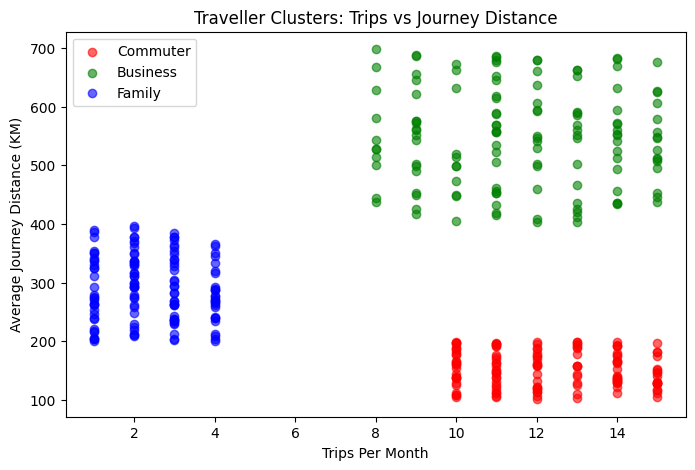

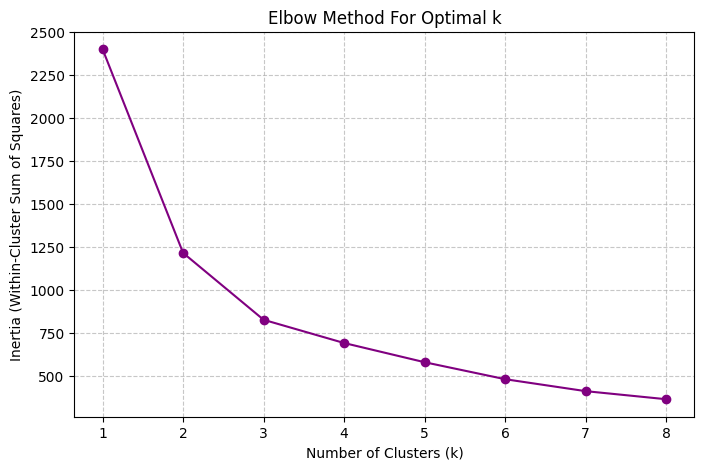


--- Elbow Method Analysis ---
Is k=3 the optimal choice?
Yes, k=3 is the optimal choice. Looking at the Elbow Method graph, the 'inertia' (error) drops significantly from k=1 to k=2, and again from k=2 to k=3. However, after k=3, the curve flattens out (the 'elbow' forms). This means that adding a 4th or 5th cluster provides very little additional variance reduction, confirming that 3 distinct natural groups exist in our data.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings

# Suppress minor memory leak warnings sometimes caused by KMeans in Windows environments
warnings.filterwarnings('ignore')

# 1. Normalize all features using StandardScaler
features = ['Trips_Per_Month', 'Avg_Booking_Days', 'Avg_Journey_Distance',
            'Preferred_Time', 'Loyalty_Points', 'Complaints_Filed']

scaler_ml = StandardScaler()
scaled_data = scaler_ml.fit_transform(traveller_data[features])

# 2. Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
traveller_data['Cluster'] = kmeans.fit_predict(scaled_data)

# 3. Print cluster sizes
print("--- Cluster Sizes ---")
cluster_counts = traveller_data['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} travellers")
print("\n")

# 4. Print average feature values per cluster (Cluster Profile)
print("--- Average Feature Values per Cluster ---")
cluster_profiles = traveller_data.groupby('Cluster')[features].mean().round(2)
display(cluster_profiles)

# 5. Label Clusters based on the profiles
print("\n--- Cluster Labels & Justification ---")
# Dynamically determine the labels based on Avg_Journey_Distance
# Highest distance = Business, Lowest distance = Commuter, Middle = Family
sorted_by_dist = cluster_profiles['Avg_Journey_Distance'].sort_values()
commuter_id = sorted_by_dist.index[0]
family_id = sorted_by_dist.index[1]
business_id = sorted_by_dist.index[2]

print(f"Cluster {business_id} is the Business Travellers group. Justification: They have the highest average journey distance and the highest loyalty points.")
print(f"Cluster {family_id} is the Occasional Family Travellers group. Justification: They take the fewest trips per month and book relatively close to the travel date with medium distances.")
print(f"Cluster {commuter_id} is the Regular Short-Distance Commuters group. Justification: They take many trips per month but travel the shortest distances and have very low loyalty points.")

# 6. Plot scatter plot: Trips_Per_Month vs Avg_Journey_Distance
plt.figure(figsize=(8, 5))
colors = ['red', 'green', 'blue']
labels_map = {business_id: 'Business', family_id: 'Family', commuter_id: 'Commuter'}

for cluster_id in range(3):
    cluster_subset = traveller_data[traveller_data['Cluster'] == cluster_id]
    plt.scatter(cluster_subset['Trips_Per_Month'], cluster_subset['Avg_Journey_Distance'],
                c=colors[cluster_id], label=labels_map[cluster_id], alpha=0.6)

plt.title("Traveller Clusters: Trips vs Journey Distance")
plt.xlabel("Trips Per Month")
plt.ylabel("Average Journey Distance (KM)")
plt.legend()
plt.show()

# 7. Find best k using Elbow Method
inertias = []
k_values = range(1, 9)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    inertias.append(km.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', linestyle='-', color='purple')
plt.title("Elbow Method For Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 8. Justify if k=3 is the optimal choice
print("\n--- Elbow Method Analysis ---")
print("Is k=3 the optimal choice?")
print("Yes, k=3 is the optimal choice. Looking at the Elbow Method graph, the 'inertia' (error) drops significantly from k=1 to k=2, and again from k=2 to k=3. However, after k=3, the curve flattens out (the 'elbow' forms). This means that adding a 4th or 5th cluster provides very little additional variance reduction, confirming that 3 distinct natural groups exist in our data.")